# Age Prediction with Computer Vision / Predicción de edad con visión computacional

This project uses a convolutional neural network based on ResNet50 to estimate a person's age from facial images.

Este proyecto utiliza una red neuronal convolucional basada en ResNet50 para estimar la edad de una persona a partir de imágenes faciales.

## 1. Initial Setup / Inicialización


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator


## 2. Data Loading / Carga de datos


The dataset is stored locally in the `faces/` folder and contains:

- `labels.csv`: file with the image names and the real age of each person.
- `final_files/`: folder containing the facial images.

Since the dataset contains thousands of images, the images are loaded using `ImageDataGenerator` instead of reading all files into memory at once.

---

El conjunto de datos se almacena localmente en la carpeta `faces/` y contiene:

- `labels.csv`: archivo con los nombres de las imágenes y la edad real de cada persona.
- `final_files/`: carpeta que contiene las imágenes faciales.

Dado que el conjunto contiene miles de imágenes, se utiliza `ImageDataGenerator` para cargar las imágenes por lotes, evitando leer todos los archivos en memoria al mismo tiempo.


In [2]:
labels = pd.read_csv('faces/labels.csv')
labels.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [3]:
labels.info()
labels.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


In [4]:
print(f"Dataset shape: {labels.shape}")
labels['real_age'].value_counts().sort_index().head()


Dataset shape: (7591, 2)


real_age
1    149
2     88
3     25
4    101
5     87
Name: count, dtype: int64

In [5]:
datagen = ImageDataGenerator(rescale=1./255)

gen_flow = datagen.flow_from_dataframe(
    dataframe=labels,
    directory='faces/final_files',
    x_col='file_name',
    y_col='real_age',
    target_size=(224, 224),
    batch_size=16,
    class_mode='raw',
    seed=12345
)

Found 7591 validated image filenames.


## 3. Exploratory Data Analysis / Análisis exploratorio de datos


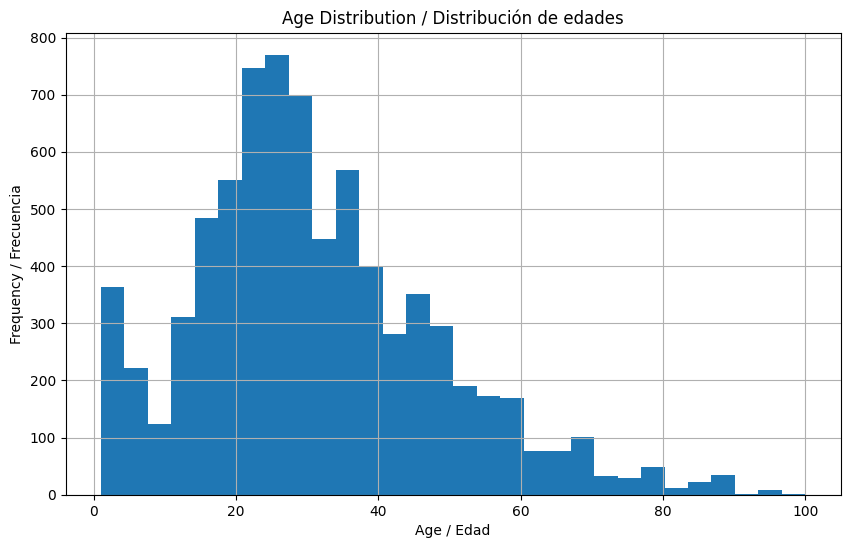

In [6]:
plt.figure(figsize=(10, 6))
labels['real_age'].hist(bins=30)
plt.title('Age Distribution / Distribución de edades')
plt.xlabel('Age / Edad')
plt.ylabel('Frequency / Frecuencia')
plt.show()


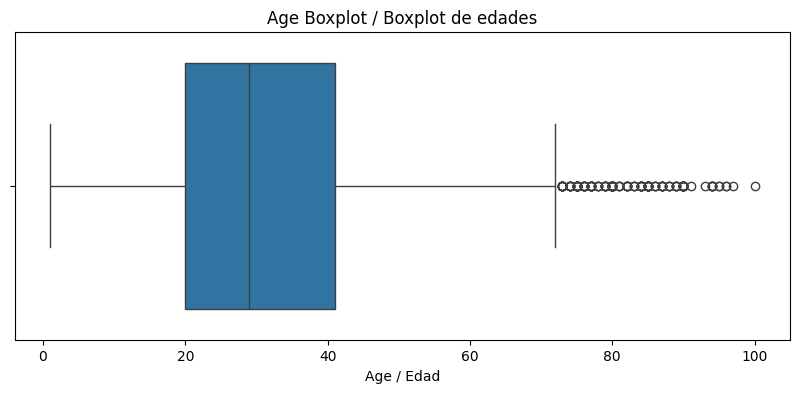

In [7]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=labels['real_age'])
plt.title('Age Boxplot / Boxplot de edades')
plt.xlabel('Age / Edad')
plt.show()


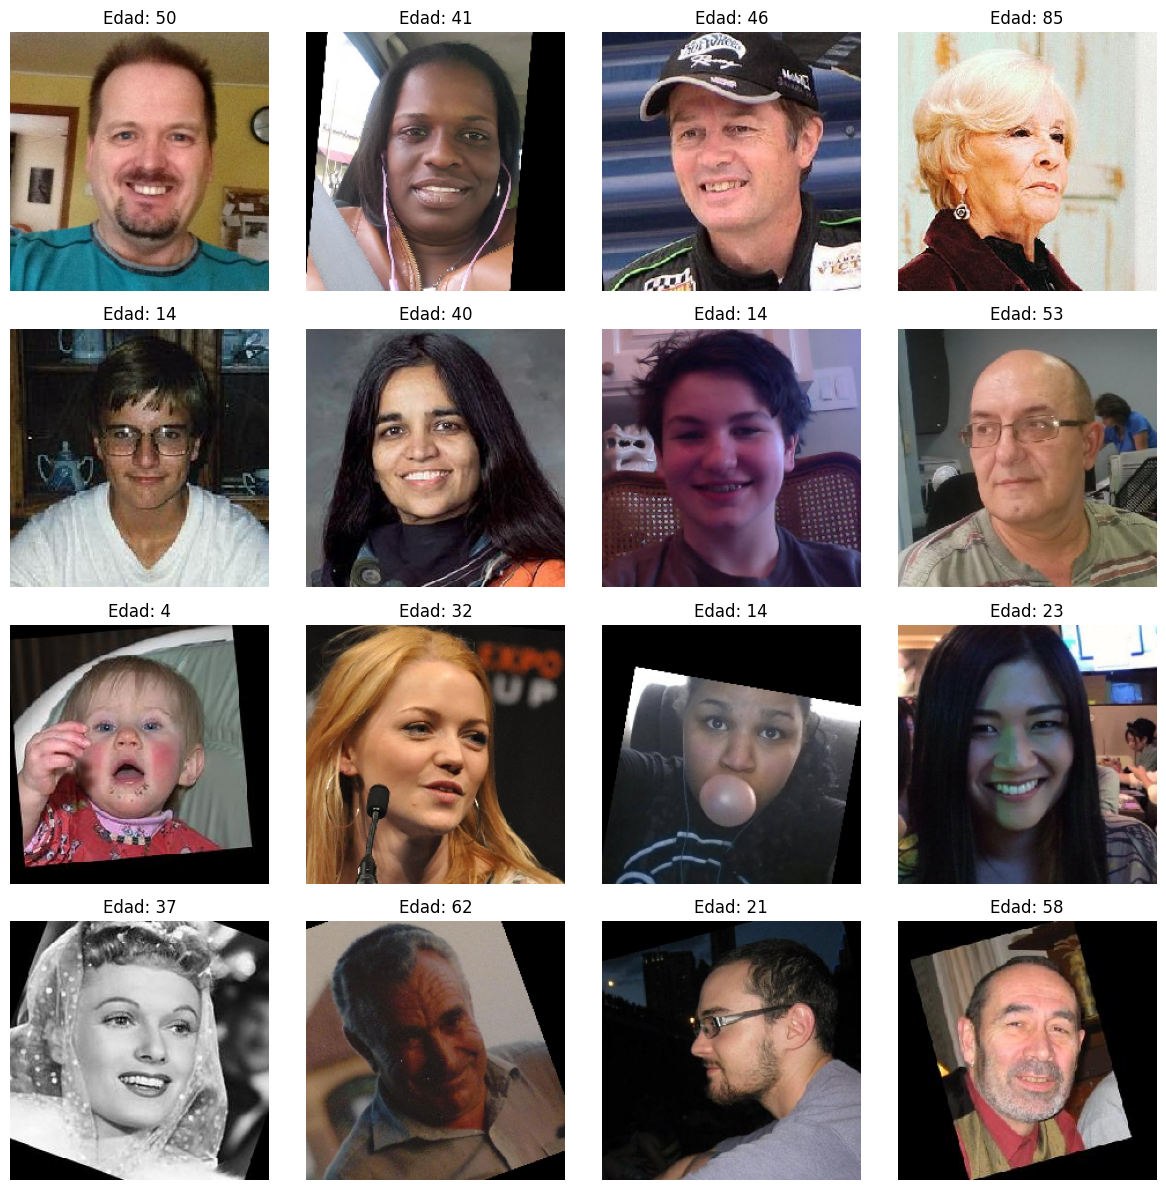

In [8]:
features, target = next(gen_flow)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    ax.imshow(features[i])
    ax.set_title(f'Edad: {int(target[i])}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### EDA Conclusions / Conclusiones del EDA


The dataset contains 7,591 facial images, each associated with a real age label.

Based on the exploratory analysis:

- The average age is approximately 31 years, with a standard deviation close to 17 years, indicating a wide age distribution.
- Most observations are concentrated between 20 and 40 years old, which means the model has more examples in this range.
- There are outliers, especially among older ages, which may make predictions more difficult for less represented age groups.
- The age distribution is not completely uniform, so the model may perform better on more frequent age ranges.

Regarding the images:

- There is variability in lighting, angles, facial expressions and image quality.
- Some images include tilted faces or cropped areas, which adds complexity to the prediction task.
- The dataset includes diverse people and age ranges, which is useful for training a computer vision model.

Using `ImageDataGenerator` is appropriate because it allows the model to process the images in batches without overloading memory.

---

El conjunto de datos contiene 7,591 imágenes de rostros, cada una asociada con una etiqueta de edad real.

A partir del análisis exploratorio:

- La edad promedio es aproximadamente 31 años, con una desviación estándar cercana a 17 años, lo que indica una distribución amplia.
- La mayoría de las observaciones se concentra entre los 20 y 40 años, por lo que el modelo cuenta con más ejemplos en este rango.
- Existen valores extremos, especialmente en edades avanzadas, lo que puede dificultar las predicciones en grupos de edad menos representados.
- La distribución de edades no es completamente uniforme, por lo que el modelo podría tener mejor desempeño en los rangos de edad más frecuentes.

Respecto a las imágenes:

- Existe variabilidad en iluminación, ángulos, expresiones faciales y calidad de imagen.
- Algunas imágenes presentan rostros inclinados o recortes, lo que añade complejidad a la tarea de predicción.
- El conjunto incluye diversidad de personas y rangos de edad, lo cual es útil para entrenar un modelo de visión computacional.

El uso de `ImageDataGenerator` es adecuado porque permite procesar las imágenes por lotes sin sobrecargar la memoria.


## 4. Modeling / Modelado


The following functions define the data loaders, model architecture and training process used on the GPU platform.

The model is based on ResNet50 with pretrained ImageNet weights. The training function includes callbacks requested by the reviewer:

- `EarlyStopping` to stop training when validation MAE stops improving.
- `ReduceLROnPlateau` to reduce the learning rate when the model reaches a plateau.
- Registration of the best validation MAE from the training history.

---

Las siguientes funciones definen la carga de datos, la arquitectura del modelo y el proceso de entrenamiento utilizado en la plataforma GPU.

El modelo se basa en ResNet50 con pesos preentrenados de ImageNet. La función de entrenamiento incluye los callbacks solicitados por el revisor:

- `EarlyStopping` para detener el entrenamiento cuando el MAE de validación deja de mejorar.
- `ReduceLROnPlateau` para reducir la tasa de aprendizaje cuando el modelo se estanca.
- Registro del mejor MAE de validación a partir del historial de entrenamiento.


In [9]:
import os
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [10]:
def load_train(path):
    """
    Loads the training subset from the dataset path.
    Carga el subconjunto de entrenamiento desde la ruta del dataset.
    """

    labels = pd.read_csv(os.path.join(path, 'labels.csv'))

    train_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255,
        horizontal_flip=True
    )

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_gen_flow


In [11]:
def load_test(path):
    """
    Loads the validation subset from the dataset path.
    Carga el subconjunto de validación desde la ruta del dataset.
    """

    labels = pd.read_csv(os.path.join(path, 'labels.csv'))

    test_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_gen_flow


In [12]:
def create_model(input_shape):
    """
    Creates a ResNet50-based regression model for age prediction.
    Crea un modelo de regresión basado en ResNet50 para predecir edad.
    """

    backbone = ResNet50(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0001)

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model


In [13]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    """
    Trains the model using callbacks to stabilize training.

    - EarlyStopping restores the best weights when validation MAE stops improving.
    - ReduceLROnPlateau reduces the learning rate when validation MAE plateaus.
    - The best validation MAE and the best epoch are stored from the training history.

    Entrena el modelo usando callbacks para estabilizar el entrenamiento.

    - EarlyStopping restaura los mejores pesos cuando el MAE de validación deja de mejorar.
    - ReduceLROnPlateau reduce la tasa de aprendizaje cuando el MAE de validación se estanca.
    - El mejor MAE de validación y la mejor época se guardan a partir del historial.
    """

    callbacks = [
        EarlyStopping(
            monitor='val_mae',
            patience=5,
            mode='min',
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_mae',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            mode='min',
            verbose=1
        )
    ]

    history = model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=2
    )

    val_mae_history = history.history.get('val_mae', [])

    if val_mae_history:
        best_val_mae = min(val_mae_history)
        best_epoch = val_mae_history.index(best_val_mae) + 1

        print(f"Best validation MAE: {best_val_mae:.4f}")
        print(f"Best epoch: {best_epoch}")

        model.best_val_mae = float(best_val_mae)
        model.best_epoch = int(best_epoch)
        model.training_history = history.history
    else:
        print("Validation MAE was not found in the training history.")

    return model


## 5. GPU Script Preparation / Preparación del script para GPU


The following cell creates a Python script with the model functions so it can be executed on the GPU platform.

La siguiente celda crea un script de Python con las funciones del modelo para poder ejecutarlo en la plataforma GPU.


In [14]:
# Prepare a script to run the model on the GPU platform.
# Prepara un script para ejecutar el modelo en la plataforma GPU.

init_str = """
import os
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    f.write(init_str)
    f.write('\n\n')

    for fn_name in [load_train, load_test, create_model, train_model]:
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')


## 6. GPU Training Results / Resultados del entrenamiento en GPU


The following log summarizes the model training results obtained on the GPU platform.

El siguiente registro resume los resultados del entrenamiento del modelo obtenidos en la plataforma GPU.


A ResNet50-based model was trained to predict age from facial images.

The best validation result was obtained at epoch 5, with a validation MAE of **6.9033**. This value meets the project criterion because it is below the required threshold of 8.

The updated training function now also records the best validation MAE directly from `history.history` and includes the callbacks `EarlyStopping` and `ReduceLROnPlateau` to stabilize training.

### Training log / Registro de entrenamiento

| Epoch | Loss | MAE | Validation Loss | Validation MAE |
|---:|---:|---:|---:|---:|
| 1 | 222.4811 | 10.9134 | 453.1367 | 16.2137 |
| 2 | 71.3394 | 6.8657 | 436.6058 | 15.8416 |
| 3 | 107.9902 | 7.8882 | 181.7797 | 9.9253 |
| 4 | 39.6030 | 4.8887 | 180.9419 | 9.9053 |
| 5 | 84.1989 | 6.9530 | 84.8499 | 6.9033 |
| 6 | 168.4181 | 9.9451 | 88.6860 | 7.0688 |
| 7 | 69.9614 | 6.3587 | 88.3365 | 7.1190 |
| 8 | 134.6575 | 9.0228 | 93.0140 | 7.3458 |
| 9 | 58.5971 | 5.8103 | 100.3019 | 7.5733 |
| 10 | 55.1781 | 5.4889 | 103.5143 | 7.7150 |

---

Se entrenó un modelo basado en ResNet50 para predecir la edad a partir de imágenes faciales.

El mejor resultado de validación se obtuvo en la época 5, con un MAE de validación de **6.9033**. Este valor cumple con el criterio del proyecto porque está por debajo del umbral requerido de 8.

La función de entrenamiento actualizada también registra el mejor MAE de validación directamente desde `history.history` e incluye los callbacks `EarlyStopping` y `ReduceLROnPlateau` para estabilizar el entrenamiento.


## 7. Conclusions / Conclusiones


The ResNet50-based computer vision model achieved satisfactory performance for age prediction from facial images. The best validation MAE was **6.9033**, which meets the project requirement because the mean absolute error is below 8 years.

This result indicates that computer vision can help estimate age automatically with a reasonable margin of error. Although the model does not predict the exact age in every case, its performance is useful for practical scenarios where an approximate age estimate is sufficient.

Potential business applications include:

- automatic age estimation for customers in stores or digital platforms;
- user segmentation by age group;
- support for access control in age-restricted products or services;
- demographic analysis for marketing and advertising;
- personalization of offers or content based on estimated age range.

The best validation result was reached in an intermediate epoch, after which validation error started to increase slightly. This suggests early signs of overfitting, which justifies the use of callbacks such as `EarlyStopping` and `ReduceLROnPlateau` in the final training function.

---

El modelo de visión computacional basado en ResNet50 logró un desempeño satisfactorio para predecir la edad a partir de imágenes faciales. El mejor MAE de validación fue **6.9033**, lo cual cumple con el requisito del proyecto porque el error medio absoluto es menor a 8 años.

Este resultado indica que la visión computacional puede ayudar a estimar la edad de forma automática con un margen de error razonable. Aunque el modelo no predice la edad exacta en todos los casos, su desempeño es útil para escenarios prácticos donde una estimación aproximada es suficiente.

Entre las posibles aplicaciones de negocio se encuentran:

- estimación automática de edad de clientes en tiendas o plataformas digitales;
- segmentación de usuarios por grupos de edad;
- apoyo en control de acceso a productos o servicios con restricciones de edad;
- análisis demográfico para marketing y publicidad;
- personalización de ofertas o contenidos según el rango de edad estimado.

El mejor resultado de validación se alcanzó en una época intermedia y después el error de validación comenzó a aumentar ligeramente. Esto sugiere señales tempranas de sobreajuste, lo cual justifica el uso de callbacks como `EarlyStopping` y `ReduceLROnPlateau` en la función final de entrenamiento.
